In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model
import warnings
warnings.filterwarnings("ignore")

### Cargamos el dataset

In [2]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml("credit-g", as_frame=True, parser="auto", return_X_y=True)

In [3]:
# Dummies y transforma la y
y = y == 'good'

X = pd.get_dummies(X)

In [4]:
# Que tan balanceado está
y.mean()

0.7

### Crea un modelo 

In [5]:
# Crea rápidamente una regresión logistica
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=0)


model = linear_model.LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Concepto odds

Mi equipo gana 1 a 4


In [6]:
odds = 1/4
odds

0.25

Probabilidad de ganar 

In [7]:
p_ganar = 1/(1+4)
p_ganar

0.2

Probabilidad perder

In [8]:
1 - p_ganar

0.8

Mi equipo gana 5 a 3

In [9]:
5/3

1.6666666666666667

Probabilidad que equipo gane 

In [10]:
p = 5 / (5+3)
p

0.625

Probabilidd de perder

In [11]:
p/(1-p)

1.6666666666666667

¿Qué pasa si divido la probabilidad de ganar entre la probabiliad de perder?

$$odds = \frac{p}{1-p}$$


$$log(\frac{p}{1-p}) = \Theta ^T X$$


Aplicamos la exponencial en ambos lados:

$$
e^{\Theta ^T X} = \frac{p}{1 - p}
$$

Despejamos \( p \):

$$
p = \frac{e^{\Theta ^T X}}{1 + e^{\Theta ^T X}}
$$

Simplificando

$$
p= \frac{1}{1 + e^{-\Theta ^T X}}
$$

Calcula los odds de las predicciones

In [12]:
#model.predict_log_proba(X)

In [13]:
# Predicciones
predicciones = model.predict_proba(X)[:,1]

# Odds
odds = predicciones / (1-predicciones)

Los odds pueden llegar a ser muy volatiles

In [14]:
log_odds = np.log(odds)

$$log(odds) = log(\frac{p}{1-p})$$

Pero el log odds no es tan disperso

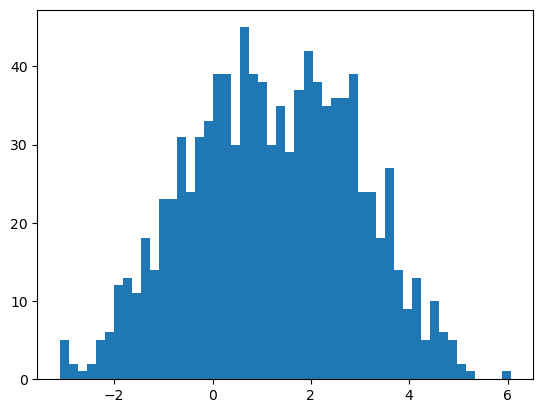

In [15]:
# Calcula y grafica los log odds
plt.hist(log_odds, bins=50)
plt.show()

### ¿Y esto que? 

Si tomamos los coeficientes de una regresión logistica como si gura una regresión lineal, obtenemos un numero extraño

$$z = \Theta ^T X $$



In [16]:
# Calcula Z
z = model.intercept_ + (model.coef_ * X).sum(axis=1)

In [17]:
X

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_0<=X<200,checking_status_<0,checking_status_>=200,...,housing_own,housing_rent,job_high qualif/self emp/mgmt,job_unemp/unskilled non res,job_unskilled resident,job_skilled,own_telephone_none,own_telephone_yes,foreign_worker_no,foreign_worker_yes
0,6,1169,4,4,67,2,1,False,True,False,...,True,False,False,False,False,True,False,True,False,True
1,48,5951,2,2,22,1,1,True,False,False,...,True,False,False,False,False,True,True,False,False,True
2,12,2096,2,3,49,1,2,False,False,False,...,True,False,False,False,True,False,True,False,False,True
3,42,7882,2,4,45,1,2,False,True,False,...,False,False,False,False,False,True,True,False,False,True
4,24,4870,3,4,53,2,2,False,True,False,...,False,False,False,False,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1,False,False,False,...,True,False,False,False,True,False,True,False,False,True
996,30,3857,4,4,40,1,1,False,True,False,...,True,False,True,False,False,False,False,True,False,True
997,12,804,4,4,38,1,1,False,False,False,...,True,False,False,False,False,True,True,False,False,True
998,45,1845,4,4,23,1,1,False,True,False,...,False,False,False,False,False,True,False,True,False,True


In [18]:
model.coef_

array([[-2.26711941e-02, -1.26199507e-04, -3.09883430e-01,
         3.03929579e-01,  1.36203510e-02, -1.60043324e-01,
         8.16401038e-02, -2.02265474e-01, -9.84890297e-01,
         2.73696227e-01,  1.17247719e+00, -3.62710706e-01,
         6.61492610e-01,  2.49778161e-02,  2.59674861e-01,
        -3.24416931e-01,  2.58861121e-02, -5.42035499e-01,
         6.73314028e-01, -1.53231265e-01, -1.37431407e-01,
         1.02385432e-01,  7.42309753e-02,  3.54440383e-01,
        -1.79808951e-01,  4.12678429e-02, -2.40863388e-01,
         1.94923144e-01, -4.37702897e-01,  2.60134641e-02,
         7.16647327e-01,  1.50291026e-01,  5.46727592e-01,
        -5.31268367e-01,  7.78391409e-02,  1.54282586e-02,
         2.75673584e-01, -1.61134114e-01,  7.69996388e-02,
         6.74785430e-02, -9.83713009e-02,  2.46871631e-01,
         1.10517321e-01,  8.26150681e-02, -3.21482102e-01,
         5.93010869e-01, -9.51261837e-02,  8.56095049e-03,
         4.10983375e-01, -1.60526675e-01,  5.38482241e-0

Resulta ser que z es lo mismo que log odds

In [19]:
df_comprobacion = pd.DataFrame({
    'z': z,
    'log_odds': log_odds
})
df_comprobacion

,z,log_odds
0,3.558252,3.558252
1,0.700230,0.700230
2,3.834249,3.834249
3,-0.006323,-0.006323
4,-1.395098,-1.395098
...,...,...
995,3.593115,3.593115
996,0.443569,0.443569
997,2.777919,2.777919
998,-0.629873,-0.629873


In [20]:
1 / (1+np.exp(-z))

0      0.972301
1      0.668239
2      0.978840
3      0.498419
4      0.198595
         ...   
995    0.973224
996    0.609109
997    0.941471
998    0.347539
999    0.767488
Length: 1000, dtype: float64

### Esto es importante porque de aquí sale sigmoide

$$log(\frac{p}{1-p}) = \Theta ^T X$$


Aplicamos la exponencial en ambos lados:

$$
e^{\Theta ^T X} = \frac{p}{1 - p}
$$

Despejamos \( p \):

$$
p = \frac{e^{\Theta ^T X}}{1 + e^{\Theta ^T X}}
$$

Simplificando

$$
p= \frac{1}{1 + e^{-\Theta ^T X}}
$$

Comprobando

### _Comprobamos que Sklearn opera conforme a la teoría_ 

### Comparando diferentes tipos de regresiones

#### Modelo lineal


#### Checando los coeficientes

## ¿Qué significa esto? 

### Log loss

$$
\text{LogLoss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]
$$

### Crea una regresión logistica 

In [21]:
from sklearn.metrics import log_loss, accuracy_score

In [22]:
predicciones_1_0 = model.predict(X)

In [23]:
accuracy_score(y_pred=predicciones_1_0, y_true=y)

0.754

In [24]:
log_loss(y_pred=predicciones, y_true=y)

0.4844566419342835

## Polinomial

In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


penalty='l2'
scoring='neg_log_loss'

In [26]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scale', StandardScaler()),
    ('logistic', linear_model.LogisticRegression())
])

params = {
    'poly__degree': [2,3]
}

grid = GridSearchCV(estimator=pipeline, cv=5, param_grid=params, scoring='roc_auc', n_jobs=-1)

grid.fit(X_train, y_train)



,estimator,Pipeline(step...egression())])
,param_grid,"{'poly__degree': [2, 3]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,degree,2


In [27]:
grid.best_params_

{'poly__degree': 2}

In [28]:
predicciones_grid = grid.predict(X_test)
accuracy_score(predicciones_grid, y_test)

0.718

In [29]:
model_linear = linear_model.LogisticRegression().fit(X_train, y_train)
predicciones_linear = model_linear.predict(X_test)
accuracy_score(predicciones_linear, y_test)

0.734

## Comparación de histogramas

In [30]:
df_hist= pd.DataFrame({
    'y': y_test,
    'poly': grid.predict_proba(X_test)[:,1],
    'lineal': model_linear.predict_proba(X_test)[:,1]
})

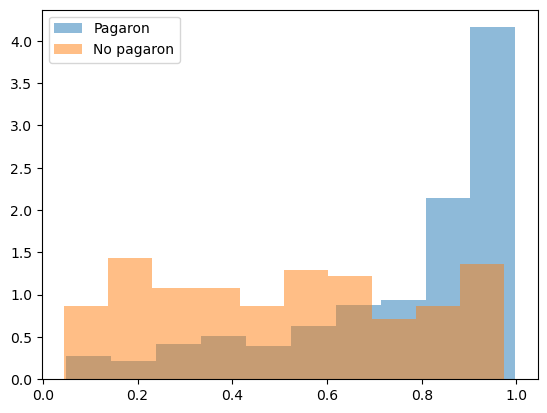

In [31]:
plt.hist(df_hist.query("y == 1")['lineal'], alpha=0.5, label="Pagaron", density=True)
plt.hist(df_hist.query("y == 0")['lineal'], alpha=0.5, label="No pagaron", density=True)
plt.legend()
plt.show()

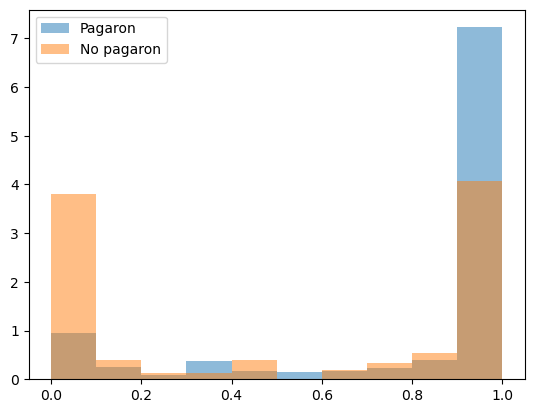

In [32]:
plt.hist(df_hist.query("y == 1")['poly'], alpha=0.5, label="Pagaron", density=True)
plt.hist(df_hist.query("y == 0")['poly'], alpha=0.5, label="No pagaron", density=True)
plt.legend()
plt.show()

## Calibracion

In [33]:
df_hist['bins_poly'] = pd.qcut(df_hist['poly'], q=10, labels=False)
df_hist['bins_lineal'] = pd.qcut(df_hist['lineal'], q=10, labels=False)

# Bivariate df
bivariate_poly = df_hist.groupby('bins_poly').mean()
bivariate_lineal = df_hist.groupby('bins_lineal').mean()

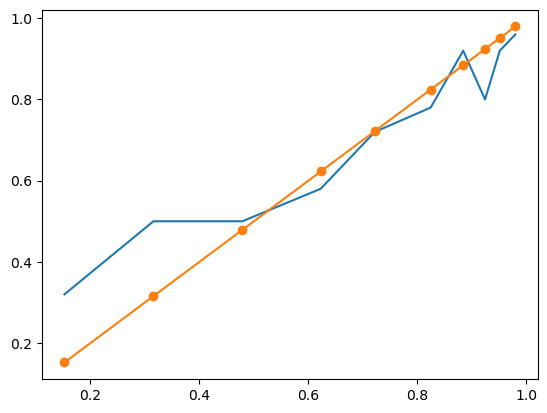

In [34]:
plt.plot(bivariate_lineal.lineal, bivariate_lineal.y)
plt.plot(bivariate_lineal.lineal, bivariate_lineal.lineal, marker="o")


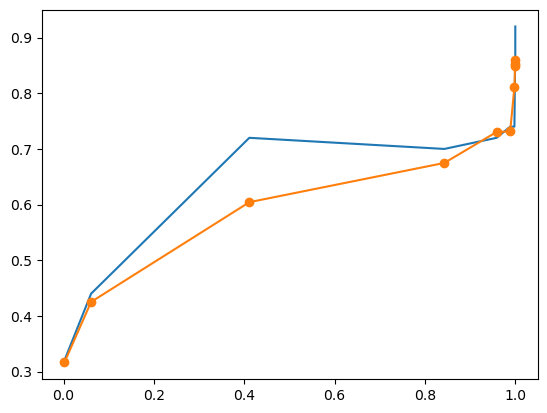

In [35]:
plt.plot(bivariate_poly.poly, bivariate_poly.y)
plt.plot(bivariate_poly.poly, bivariate_poly.lineal, marker="o")


In [36]:
bivariate_poly

,y,poly,lineal,bins_lineal
bins_poly,,,,
0,0.32,0.001813,0.316386,1.18
1,0.44,0.060926,0.425192,2.00
2,0.72,0.411210,0.604353,3.42
3,0.70,0.842910,0.674860,4.06
4,0.72,0.958668,0.730482,4.46
5,0.74,0.988615,0.731512,4.66
6,0.74,0.998036,0.810636,5.76
7,0.86,0.999635,0.853459,6.20
8,0.84,0.999959,0.848865,6.42
